In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
from src.utils.utils import set_seed
set_seed(0) 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint
checkpoint_dir = Path("../checkpoints/mixer_tpp_20260202-204248") 
checkpoint_path = checkpoint_dir / "last_model_1.pth"
check_point = torch.load(checkpoint_path,weights_only=False)
args = load_args_from_checkpoint(None, check_point)
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
model = torch.compile(model)
model.eval() 

MixerTPP context size: 64
load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'mixer_tpp', 'num_event_types': 1, 'pad_token_id': 1, 'task_type': 'tpp', 'batch_size': 1, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 0.01, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'hf_cosine', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.8, 'use_amp': False, 'dropout': 0.3, 'd_model': 64, 'mixer_model_config': {'input_dim': 1, 'dropout_prob': 0.1, 'd_model': 64, 'n_layer': 1, 'd_intermediate': 128, 'attn_layer_idx': [], 'input_proj_type': 'mlp', 'input_proj_hidden': 128, 'input_proj_activation': 'silu', 'input_proj_dropout': 0.1, 'input_init': 'kaiming_uniform', 'input_init_scale': 1.5, 'ssm_cfg': {'layer': 'Mamba2Rotary', 'use_conv': False, 'rotary_emb_scale_base': 2048}, 'attn_cfg': {'layer': 'MHATime', 'num_heads': 4, 'r

OptimizedModule(
  (_orig_mod): MixerTPP(
    (base_model): MixerModelWrapper(
      (encoder): MixerModel(
        (input_proj): Sequential(
          (0): Linear(in_features=1, out_features=128, bias=True)
          (1): SiLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=128, out_features=64, bias=True)
        )
        (dropout): Dropout(p=0.1, inplace=False)
        (layers): ModuleList(
          (0): Block(
            (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mixer): Mamba2Rotary(
              (in_proj): Linear(in_features=64, out_features=514, bias=False)
              (act): SiLU()
              (norm): RMSNorm()
              (out_proj): Linear(in_features=128, out_features=64, bias=False)
              (rotary_emb): RotaryEmbeddingTime()
            )
            (dropout): Dropout(p=0.1, inplace=False)
            (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mlp): GatedMLP(
  

In [3]:
model.base_model.encoder.layers[0]

Block(
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (mixer): Mamba2Rotary(
    (in_proj): Linear(in_features=64, out_features=514, bias=False)
    (act): SiLU()
    (norm): RMSNorm()
    (out_proj): Linear(in_features=128, out_features=64, bias=False)
    (rotary_emb): RotaryEmbeddingTime()
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (mlp): GatedMLP(
    (fc1): Linear(in_features=64, out_features=256, bias=False)
    (fc2): Linear(in_features=128, out_features=64, bias=False)
  )
)

In [4]:
from src.data.preparation import prepare_data_tpp
base_dir = f"../data/{args.dataset}"
df, train_loader, val_loader, test_loader, catalog_ds = prepare_data_tpp(base_dir=base_dir, args=args,)

Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/AZDX/raw.
Using Bayesian GR b-value updater with delta=0.98, a0=50.0, init b=1.0000, mag_completeness=4.5
TPP pretrain mode: using all splits as training, disabling val/test loaders.


  0%|          | 0/45 [00:00<?, ?it/s]

[split_sequence] t_start: 316.3100, t_end: 883.8222
[split_sequence] Window duration: 567.5122
[split_sequence] Short sequence NLL start set to 441.9111
[split_sequence] t_start: 629.4130, t_end: 1325.7333
[split_sequence] Window duration: 696.3203
[split_sequence] Short sequence NLL start set to 883.8222
[split_sequence] t_start: 1038.3400, t_end: 1767.6444
[split_sequence] Window duration: 729.3045
[split_sequence] Short sequence NLL start set to 1325.7333
[split_sequence] t_start: 1399.1500, t_end: 2209.5556
[split_sequence] Window duration: 810.4055
[split_sequence] Short sequence NLL start set to 1767.6444
[split_sequence] t_start: 1868.6000, t_end: 2651.4667
[split_sequence] Window duration: 782.8667
[split_sequence] Short sequence NLL start set to 2209.5556
[split_sequence] t_start: 2417.2000, t_end: 3093.3778
[split_sequence] Window duration: 676.1778
[split_sequence] Short sequence NLL start set to 2651.4667
[split_sequence] t_start: 2846.3999, t_end: 3535.2889
[split_sequence

/root/autodl-tmp/chuandian_eq/src/data/sequence.py:246: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


In [5]:
for batch in train_loader:
    batch = batch.to(device)
    print(batch.arrival_times)
    break

tensor([[316.3100, 316.3430, 316.5250,  ..., 883.0280, 883.6810, 883.8221]],
       device='cuda:0')


/root/autodl-tmp/tmp/ipykernel_14401/3784521066.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask).bool()


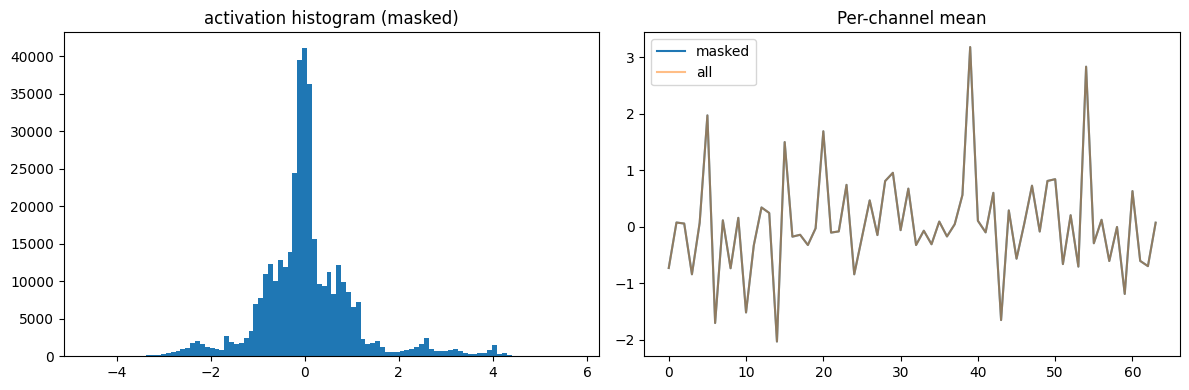

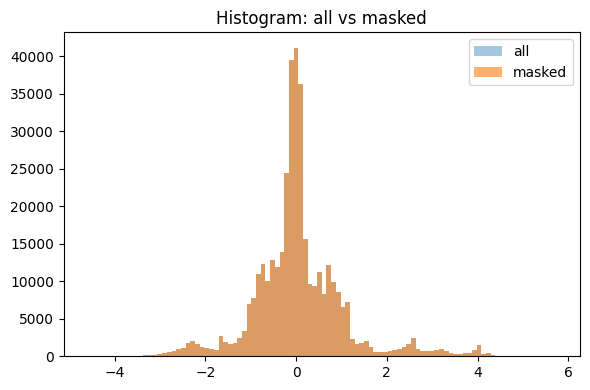

In [9]:
from src.utils.mask_utils import get_non_pad_mask
import src.utils.interpretability as interp
mask = get_non_pad_mask(batch.inter_times).squeeze(-1).cpu()
mask = torch.tensor(mask).bool()
out = interp.capture_layer_activations(model, batch, module=model.base_model.encoder, valid_mask=mask, visualize=True)